In [272]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import joblib

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import KNNImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.exceptions import NotFittedError
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import xgboost as xgb

import folium
from folium import LayerControl

# 1) Chargement des jeux de données train/test déjà générés

In [273]:
X_train = pd.read_csv('X_train.csv', index_col="idannonce")
X_test = pd.read_csv('X_test.csv', index_col="idannonce")

X_train_sans_scaler = pd.read_csv('X_train_sans_scaler.csv', index_col="idannonce")
X_test_sans_scaler = pd.read_csv('X_test_sans_scaler.csv', index_col="idannonce")

y_train = pd.read_csv('y_train.csv', index_col="idannonce")
y_test = pd.read_csv('y_test.csv', index_col="idannonce")

### On enleve le prix au m2 par rapport aux travaux précédents (et on renomme la colonne de target_encoding)

In [274]:
X_train = X_train.rename(columns={'prix_bien_target_encoding':'avg_commune_type_pieces'}).drop('prix_m2_vente', axis=1)
X_test = X_test.rename(columns={'prix_bien_target_encoding':'avg_commune_type_pieces'}).drop('prix_m2_vente', axis=1)
X_train_sans_scaler = X_train_sans_scaler.rename(columns={'prix_bien_target_encoding':'avg_commune_type_pieces'}).drop('prix_m2_vente', axis=1)
X_test_sans_scaler = X_test_sans_scaler.rename(columns={'prix_bien_target_encoding':'avg_commune_type_pieces'}).drop('prix_m2_vente', axis=1)

### On reprend les features selectionnées

In [275]:
selected_dict = joblib.load("selected_dict_12102026.joblib")

In [276]:
#si l'on regarde l'intersection entre les features sélectionnées par la PCA et les features sélectionnées par la lr:
selected = set(selected_dict['lr'][:47]).intersection(set(selected_dict['sfs'])).intersection(set(selected_dict['kbest']))
selected = list(selected)
selected

['categorie_annonceur_cm',
 'nb_toilettes',
 'expo_sud',
 'nb_pieces',
 'UU2010',
 'nb_etages',
 'eau',
 'categorie_annonceur_a',
 'dpe_B',
 'chauffage_mode_individuel',
 'avg_commune_type_pieces',
 'typedetransaction_vp',
 'annonce_exclusive_Oui',
 'nb_logements_copro',
 'annee_2022',
 'Longitude_scaled',
 'ascenseur',
 'surface_terrain',
 'balcon',
 'surface',
 'dpe_A',
 'logement_neuf',
 'bain',
 'dpeC',
 'annee_2023']

In [277]:
len(selected)

25

# 2) On découpe le jeu de données pour chercher des modèles différents

#### Découpage X et y par type de bien

In [278]:
X_train_appartements = X_train[(X_train_sans_scaler['typedebien_lite_a'] == 1)]
X_train_sans_scaler_appartements = X_train_sans_scaler[(X_train_sans_scaler['typedebien_lite_a'] == 1)]
y_train_appartements = y_train[(X_train_sans_scaler['typedebien_lite_a'] == 1)]
X_test_appartements = X_test[(X_test_sans_scaler['typedebien_lite_a'] == 1)]
X_test_sans_scaler_appartements = X_test_sans_scaler[(X_test_sans_scaler['typedebien_lite_a'] == 1)]
y_test_appartements = y_test[(X_test_sans_scaler['typedebien_lite_a'] == 1)]

X_train_maisons = X_train[(X_train_sans_scaler['typedebien_lite_m'] == 1)]
X_train_sans_scaler_maisons = X_train_sans_scaler[(X_train_sans_scaler['typedebien_lite_m'] == 1)]
y_train_maisons = y_train[(X_train_sans_scaler['typedebien_lite_m'] == 1)]
X_test_maisons = X_test[(X_test_sans_scaler['typedebien_lite_m'] == 1)]
X_test_sans_scaler_maisons = X_test_sans_scaler[(X_test_sans_scaler['typedebien_lite_m'] == 1)]
y_test_maisons = y_test[(X_test_sans_scaler['typedebien_lite_m'] == 1)]

## Découpage par nb_pieces

<Axes: xlabel='nb_pieces', ylabel='Count'>

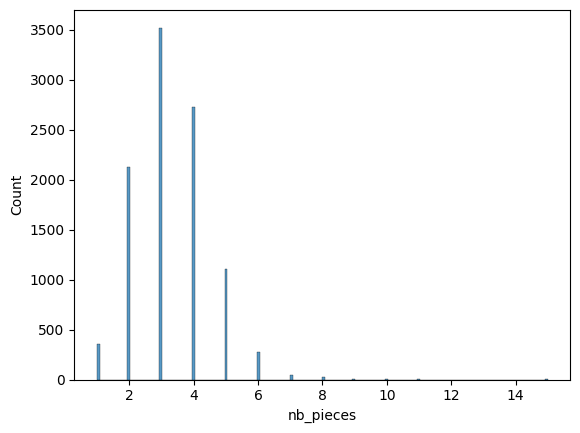

In [279]:
sns.histplot(X_train_sans_scaler_appartements.nb_pieces)

<Axes: xlabel='nb_pieces', ylabel='Count'>

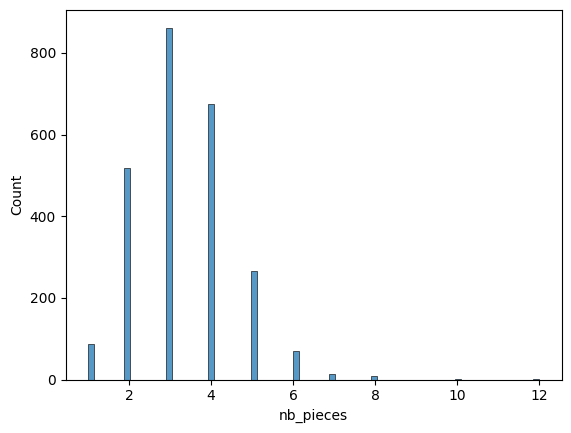

In [280]:
sns.histplot(X_test_sans_scaler_appartements.nb_pieces)

Appartement -> faire un découpage entre nb_pieces <= 3 et > 3

<Axes: xlabel='nb_pieces', ylabel='Count'>

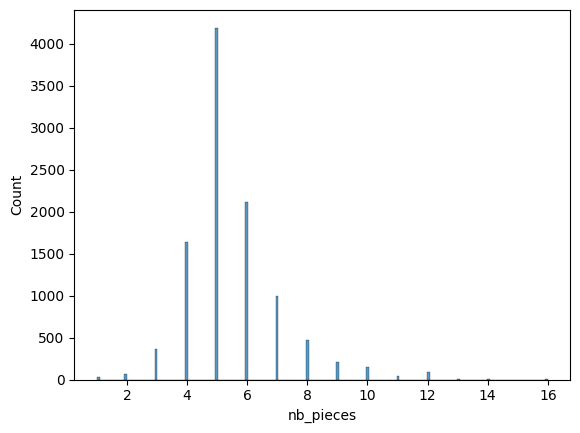

In [281]:
sns.histplot(X_train_sans_scaler_maisons.nb_pieces)

<Axes: xlabel='nb_pieces', ylabel='Count'>

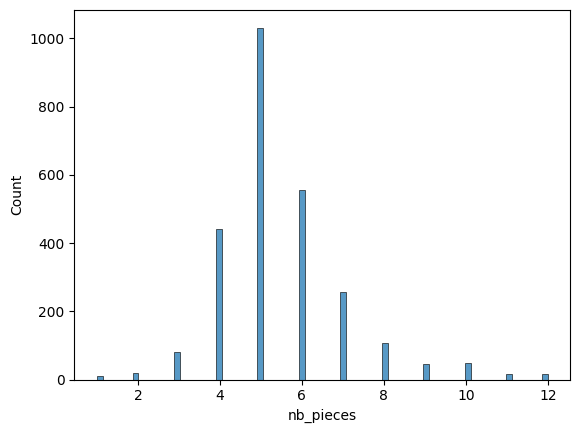

In [282]:
sns.histplot(X_test_sans_scaler_maisons.nb_pieces)

Maisons -> faire un découpage entre nb_pieces <= 5 et > 5

In [283]:
X_train_appartements_moins3 = X_train[(X_train_sans_scaler['typedebien_lite_a'] == 1) & (X_train_sans_scaler['nb_pieces'] <= 3)]
X_train_sans_scaler_appartements_moins3 = X_train_sans_scaler[(X_train_sans_scaler['typedebien_lite_a'] == 1) & (X_train_sans_scaler['nb_pieces'] <= 3)]
y_train_appartements_moins3 = y_train[(X_train_sans_scaler['typedebien_lite_a'] == 1) & (X_train_sans_scaler['nb_pieces'] <= 3)]
X_test_appartements_moins3 = X_test[(X_test_sans_scaler['typedebien_lite_a'] == 1) & (X_test_sans_scaler['nb_pieces'] <= 3)]
X_test_sans_scaler_appartements_moins3 = X_test_sans_scaler[(X_test_sans_scaler['typedebien_lite_a'] == 1) & (X_test_sans_scaler['nb_pieces'] <= 3)]
y_test_appartements_moins3 = y_test[(X_test_sans_scaler['typedebien_lite_a'] == 1) & (X_test_sans_scaler['nb_pieces'] <= 3)]

X_train_maisons_moins5 = X_train[(X_train_sans_scaler['typedebien_lite_m'] == 1) & (X_train_sans_scaler['nb_pieces'] <= 5)]
X_train_sans_scaler_maisons_moins5 = X_train_sans_scaler[(X_train_sans_scaler['typedebien_lite_m'] == 1) & (X_train_sans_scaler['nb_pieces'] <= 5)]
y_train_maisons_moins5 = y_train[(X_train_sans_scaler['typedebien_lite_m'] == 1) & (X_train_sans_scaler['nb_pieces'] <= 5)]
X_test_maisons_moins5 = X_test[(X_test_sans_scaler['typedebien_lite_m'] == 1) & (X_test_sans_scaler['nb_pieces'] <= 5)]
X_test_sans_scaler_maisons_moins5 = X_test_sans_scaler[(X_test_sans_scaler['typedebien_lite_m'] == 1) & (X_test_sans_scaler['nb_pieces'] <= 5)]
y_test_maisons_moins5 = y_test[(X_test_sans_scaler['typedebien_lite_m'] == 1) & (X_test_sans_scaler['nb_pieces'] <= 5)]

In [284]:
X_train_appartements_plus3 = X_train[(X_train_sans_scaler['typedebien_lite_a'] == 1) & (X_train_sans_scaler['nb_pieces'] > 3)]
X_train_sans_scaler_appartements_plus3 = X_train_sans_scaler[(X_train_sans_scaler['typedebien_lite_a'] == 1) & (X_train_sans_scaler['nb_pieces'] > 3)]
y_train_appartements_plus3 = y_train[(X_train_sans_scaler['typedebien_lite_a'] == 1) & (X_train_sans_scaler['nb_pieces'] > 3)]
X_test_appartements_plus3 = X_test[(X_test_sans_scaler['typedebien_lite_a'] == 1) & (X_test_sans_scaler['nb_pieces'] > 3)]
X_test_sans_scaler_appartements_plus3 = X_test_sans_scaler[(X_test_sans_scaler['typedebien_lite_a'] == 1) & (X_test_sans_scaler['nb_pieces'] > 3)]
y_test_appartements_plus3 = y_test[(X_test_sans_scaler['typedebien_lite_a'] == 1) & (X_test_sans_scaler['nb_pieces'] > 3)]

X_train_maisons_plus5 = X_train[(X_train_sans_scaler['typedebien_lite_m'] == 1) & (X_train_sans_scaler['nb_pieces'] > 5)]
X_train_sans_scaler_maisons_plus5 = X_train_sans_scaler[(X_train_sans_scaler['typedebien_lite_m'] == 1) & (X_train_sans_scaler['nb_pieces'] > 5)]
y_train_maisons_plus5 = y_train[(X_train_sans_scaler['typedebien_lite_m'] == 1) & (X_train_sans_scaler['nb_pieces'] > 5)]
X_test_maisons_plus5 = X_test[(X_test_sans_scaler['typedebien_lite_m'] == 1) & (X_test_sans_scaler['nb_pieces'] > 5)]
X_test_sans_scaler_maisons_plus5 = X_test_sans_scaler[(X_test_sans_scaler['typedebien_lite_m'] == 1) & (X_test_sans_scaler['nb_pieces'] > 5)]
y_test_maisons_plus5 = y_test[(X_test_sans_scaler['typedebien_lite_m'] == 1) & (X_test_sans_scaler['nb_pieces'] > 5)]

# 3) Modélisation

## XGBoost (MAE : 42105)

In [285]:
train = xgb.DMatrix(data=X_train, label=y_train)
test = xgb.DMatrix(data=X_test, label=y_test)

test_maisons = xgb.DMatrix(data=X_test_maisons, label=y_test_maisons)
test_maisons_moins5 = xgb.DMatrix(data=X_test_maisons_moins5, label=y_test_maisons_moins5)
test_maisons_plus5 = xgb.DMatrix(data=X_test_maisons_plus5, label=y_test_maisons_plus5)

test_appartements = xgb.DMatrix(data=X_test_appartements, label=y_test_appartements)
test_appartements_moins3 = xgb.DMatrix(data=X_test_appartements_moins3, label=y_test_appartements_moins3)
test_appartements_plus3 = xgb.DMatrix(data=X_test_appartements_plus3, label=y_test_appartements_plus3)

### Train

In [286]:
# Insérez votre code ici
params = {'colsample_bytree': 1.0, 'gamma': 0, 'learning_rate': 0.05, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 1000, 'subsample': 0.8, 'objective': 'reg:squarederror', 'eval_metric' : 'mae', 'booster' : 'gbtree'}

xgb1 = xgb.train(params=params, dtrain=train, num_boost_round=10000, evals=[(train, 'train'), (test, 'eval')])


[0]	train-mae:111652.41926	eval-mae:112067.84772
[1]	train-mae:107446.41901	eval-mae:108286.08556
[2]	train-mae:103496.38736	eval-mae:104762.91296
[3]	train-mae:99815.65387	eval-mae:101497.74649
[4]	train-mae:96307.11623	eval-mae:98367.05983


c:\Users\NKSP1012\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:49:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "n_estimators" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[5]	train-mae:93052.82677	eval-mae:95564.80950
[6]	train-mae:89904.65927	eval-mae:92810.19205
[7]	train-mae:86962.34080	eval-mae:90274.20397
[8]	train-mae:84155.21686	eval-mae:87881.66834
[9]	train-mae:81558.92618	eval-mae:85666.10991
[10]	train-mae:79158.31516	eval-mae:83628.75139
[11]	train-mae:76893.11200	eval-mae:81712.89306
[12]	train-mae:74707.70204	eval-mae:79839.85048
[13]	train-mae:72674.74261	eval-mae:78135.43802
[14]	train-mae:70727.71092	eval-mae:76550.60358
[15]	train-mae:68890.85791	eval-mae:75058.67775
[16]	train-mae:67158.49376	eval-mae:73602.14690
[17]	train-mae:65543.67638	eval-mae:72226.43508
[18]	train-mae:64018.03559	eval-mae:70945.58301
[19]	train-mae:62623.04743	eval-mae:69834.29346
[20]	train-mae:61283.73192	eval-mae:68731.62271
[21]	train-mae:60045.33795	eval-mae:67711.65117
[22]	train-mae:58853.98886	eval-mae:66721.25188
[23]	train-mae:57748.47271	eval-mae:65856.36113
[24]	train-mae:56712.25020	eval-mae:65016.72036
[25]	train-mae:55714.50476	eval-mae:64237.683

### plot_importance

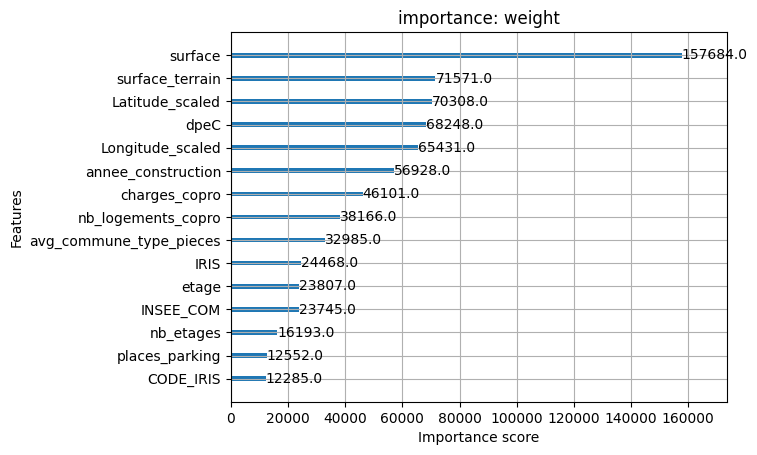

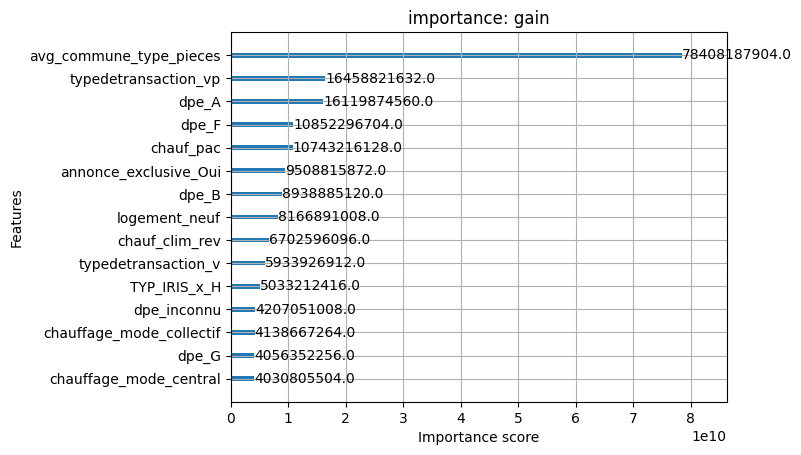

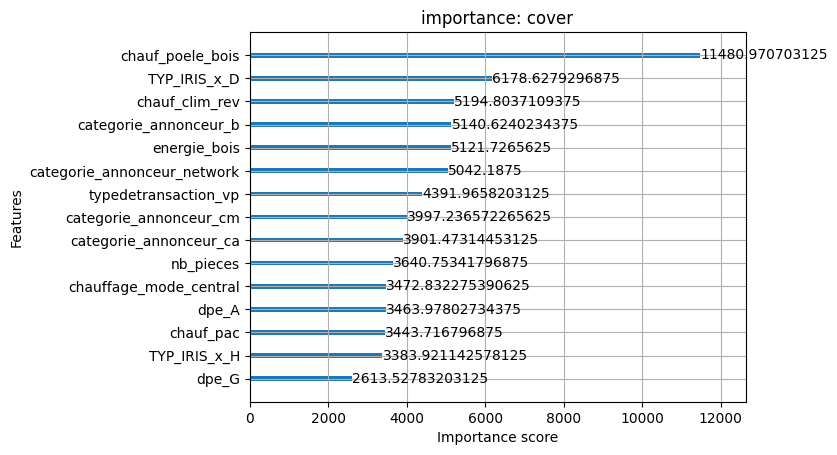

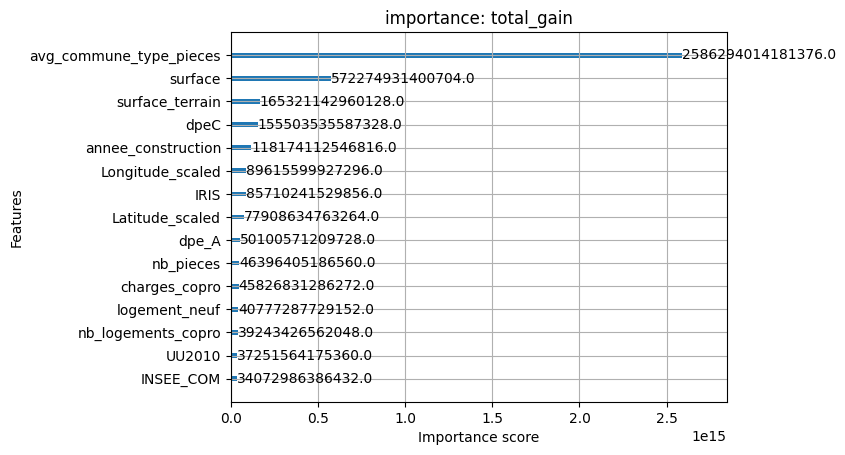

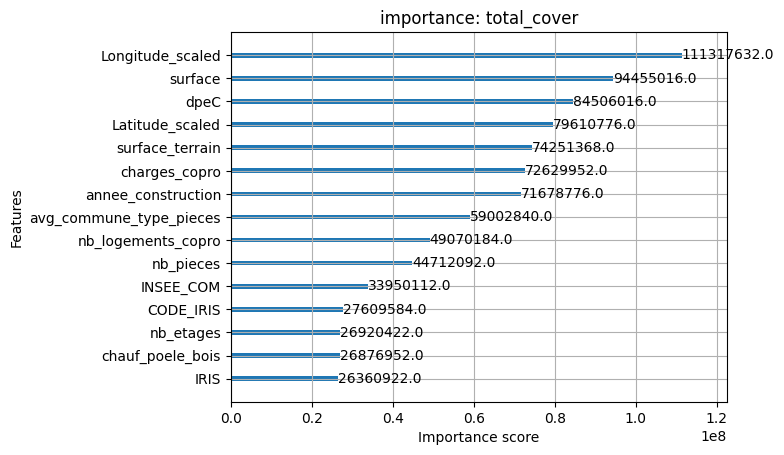

In [287]:
types= ['weight', 'gain', 'cover', 'total_gain', 'total_cover']

for f in types:
    xgb.plot_importance(xgb1 ,max_num_features=15, importance_type=f, title='importance: '+f);

### predict

In [288]:
preds = xgb1.predict(test)

preds_maisons = xgb1.predict(test_maisons)
preds_maisons_moins5 = xgb1.predict(test_maisons_moins5)
preds_maisons_plus5 = xgb1.predict(test_maisons_plus5)

preds_appartements = xgb1.predict(test_appartements)
preds_appartements_moins3 = xgb1.predict(test_appartements_moins3)
preds_appartements_plus3 = xgb1.predict(test_appartements_plus3)

In [289]:
dict_metrics_xgboost = {}
dict_metrics_xgboost['XGBoost'] = {}

### MAE maisons/appartements

In [290]:
print(f"MAE de XGBoost 10000 rounds : {abs(y_test['prix_bien'] - preds).mean()} sur {len(preds)} biens de test")
print(f"MAE de XGBoost 10000 rounds (focus test maisons): {abs(y_test_maisons['prix_bien'] - preds_maisons).mean()} sur {len(preds_maisons)} biens de test")
print(f"MAE de XGBoost 10000 rounds (focus test appartements): {abs(y_test_appartements['prix_bien'] - preds_appartements).mean()} sur {len(preds_appartements)} biens de test")

dict_metrics_xgboost['XGBoost']['MAE'] = abs(y_test['prix_bien'] - preds).mean()
dict_metrics_xgboost['XGBoost']['MAE maisons'] = abs(y_test_maisons['prix_bien'] - preds_maisons).mean()
dict_metrics_xgboost['XGBoost']['MAE appartements'] = abs(y_test_appartements['prix_bien'] - preds_appartements).mean()


MAE de XGBoost 10000 rounds : 42105.31259333248 sur 5127 biens de test
MAE de XGBoost 10000 rounds (focus test maisons): 55953.45099404762 sur 2625 biens de test
MAE de XGBoost 10000 rounds (focus test appartements): 27576.39041032799 sur 2502 biens de test


Focus sur les maisons => moins de 5 pièces vs plus de 5 pièces

In [291]:
print(f"MAE de XGBoost 10000 rounds (focus test maisons): {abs(y_test_maisons['prix_bien'] - preds_maisons).mean()} sur {len(preds_maisons)} biens de test")
print(f"MAE de XGBoost 10000 rounds (focus test maisons <= 5 pieces): {abs(y_test_maisons_moins5['prix_bien'] - preds_maisons_moins5).mean()} sur {len(preds_maisons_moins5)} biens de test")
print(f"MAE de XGBoost 10000 rounds (focus test maisons > 5 pieces): {abs(y_test_maisons_plus5['prix_bien'] - preds_maisons_plus5).mean()} sur {len(preds_maisons_plus5)} biens de test")

dict_metrics_xgboost['XGBoost']['MAE maisons <= 5 pieces'] = abs(y_test_maisons_moins5['prix_bien'] - preds_maisons_moins5).mean()
dict_metrics_xgboost['XGBoost']['MAE maisons > 5 pieces'] = abs(y_test_maisons_plus5['prix_bien'] - preds_maisons_plus5).mean()

MAE de XGBoost 10000 rounds (focus test maisons): 55953.45099404762 sur 2625 biens de test
MAE de XGBoost 10000 rounds (focus test maisons <= 5 pieces): 41494.783242582074 sur 1584 biens de test
MAE de XGBoost 10000 rounds (focus test maisons > 5 pieces): 77953.95984930356 sur 1041 biens de test


Focus sur les appartements => moins de 3 pièces vs plus de 3 pièces

In [292]:
print(f"MAE de XGBoost 10000 rounds (focus test appartements): {abs(y_test_appartements['prix_bien'] - preds_appartements).mean()} sur {len(preds_appartements)} biens de test")
print(f"MAE de XGBoost 10000 rounds (focus test appartements <= 3 pieces): {abs(y_test_appartements_moins3['prix_bien'] - preds_appartements_moins3).mean()} sur {len(preds_appartements_moins3)} biens de test")
print(f"MAE de XGBoost 10000 rounds (focus test appartements > 3 pieces): {abs(y_test_appartements_plus3['prix_bien'] - preds_appartements_plus3).mean()} sur {len(preds_appartements_plus3)} biens de test")

dict_metrics_xgboost['XGBoost']['MAE appartements <= 3 pieces'] = abs(y_test_appartements_moins3['prix_bien'] - preds_appartements_moins3).mean()
dict_metrics_xgboost['XGBoost']['MAE appartements > 3 pieces'] = abs(y_test_appartements_plus3['prix_bien'] - preds_appartements_plus3).mean()

MAE de XGBoost 10000 rounds (focus test appartements): 27576.39041032799 sur 2502 biens de test
MAE de XGBoost 10000 rounds (focus test appartements <= 3 pieces): 20627.330594697938 sur 1467 biens de test
MAE de XGBoost 10000 rounds (focus test appartements > 3 pieces): 37425.92736639493 sur 1035 biens de test


## OverSampling sur nb_pieces +-3 pour appartements et +-5 pour maisons

Equilibre des classes sur X_train et X_test pour les maisons.

In [293]:
(X_train_sans_scaler_maisons.nb_pieces <= 5).astype('uint8').value_counts()

nb_pieces
1    6288
0    4089
Name: count, dtype: int64

In [294]:
(X_test_sans_scaler_maisons.nb_pieces <= 5).astype('uint8').value_counts()

nb_pieces
1    1584
0    1041
Name: count, dtype: int64

Equilibre des classes sur X_train et X_test pour les appartements.

In [295]:
(X_train_sans_scaler_appartements.nb_pieces <= 3).astype('uint8').value_counts()

nb_pieces
1    5995
0    4197
Name: count, dtype: int64

In [296]:
(X_test_sans_scaler_appartements.nb_pieces <= 3).astype('uint8').value_counts()

nb_pieces
1    1467
0    1035
Name: count, dtype: int64

### Df pour OverSampling maisons

In [297]:
df_ros_X_train_maisons = X_train_maisons
df_ros_X_train_maisons['prix_bien'] = y_train_maisons
df_ros_X_train_maisons_plus_moins5 = (X_train_sans_scaler_maisons.nb_pieces <= 5).astype('uint8')
print('Classes avant oversampling :', dict(pd.Series(df_ros_X_train_maisons_plus_moins5).value_counts()))

Classes avant oversampling : {1: np.int64(6288), 0: np.int64(4089)}


C:\Users\NKSP1012\AppData\Local\Temp\1\ipykernel_29396\1906237942.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ros_X_train_maisons['prix_bien'] = y_train_maisons


In [298]:
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

### RandomOverSampler maisons

In [299]:
rOs_maisons = RandomOverSampler()
X_ro, y_ro = rOs_maisons.fit_resample(df_ros_X_train_maisons, df_ros_X_train_maisons_plus_moins5)
print('Classes après oversampling :', dict(pd.Series(y_ro).value_counts()))

Classes après oversampling : {1: np.int64(6288), 0: np.int64(6288)}


In [300]:
X_train_maisons_ros = X_ro.drop('prix_bien', axis=1)
y_train_maisons_ros = X_ro.prix_bien

### Df pour OverSampling appartements

In [301]:
df_ros_X_train_appartements = X_train_appartements
df_ros_X_train_appartements['prix_bien'] = y_train_appartements
df_ros_X_train_appartements_plus_moins3 = (X_train_sans_scaler_appartements.nb_pieces <= 3).astype('uint8')
print('Classes avant oversampling :', dict(pd.Series(df_ros_X_train_appartements_plus_moins3).value_counts()))

Classes avant oversampling : {1: np.int64(5995), 0: np.int64(4197)}


C:\Users\NKSP1012\AppData\Local\Temp\1\ipykernel_29396\1379286572.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ros_X_train_appartements['prix_bien'] = y_train_appartements


### RandomOverSampler appartements

In [302]:
rOs_appartements = RandomOverSampler()
X_ro, y_ro = rOs_appartements.fit_resample(df_ros_X_train_appartements, df_ros_X_train_appartements_plus_moins3)
print('Classes après oversampling :', dict(pd.Series(y_ro).value_counts()))

Classes après oversampling : {1: np.int64(5995), 0: np.int64(5995)}


In [303]:
X_train_appartements_ros = X_ro.drop('prix_bien', axis=1)
y_train_appartements_ros = X_ro.prix_bien

### X_train et y_train avec ROS

In [304]:
X_train_ros = pd.concat([X_train_maisons_ros, X_train_appartements_ros])
y_train_ros = pd.concat([y_train_maisons_ros, y_train_appartements_ros])

In [305]:
train_ros = xgb.DMatrix(data=X_train_ros, label=y_train_ros)

### XGBoost avec ROS (MAE : 42276)

In [306]:
params = {'colsample_bytree': 1.0, 'gamma': 0, 'learning_rate': 0.05, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 1000, 'subsample': 0.8, 'objective': 'reg:squarederror', 'eval_metric' : 'mae', 'booster' : 'gbtree'}

xgb_ros = xgb.train(params=params, dtrain=train_ros, num_boost_round=10000, evals=[(train_ros, 'train'), (test, 'eval')])


[0]	train-mae:116595.56396	eval-mae:113989.70741
[1]	train-mae:112208.69829	eval-mae:110119.54699
[2]	train-mae:108041.28820	eval-mae:106533.54492
[3]	train-mae:104174.00675	eval-mae:103193.71881


c:\Users\NKSP1012\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:53:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "n_estimators" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[4]	train-mae:100538.31441	eval-mae:100079.98464
[5]	train-mae:97126.61859	eval-mae:97200.45783
[6]	train-mae:93851.19598	eval-mae:94438.00927
[7]	train-mae:90765.18398	eval-mae:91782.94449
[8]	train-mae:87901.90878	eval-mae:89422.81478
[9]	train-mae:85127.66718	eval-mae:87065.91861
[10]	train-mae:82538.01591	eval-mae:84908.43713
[11]	train-mae:80155.14574	eval-mae:82861.08450
[12]	train-mae:77879.05388	eval-mae:80972.53148
[13]	train-mae:75733.23734	eval-mae:79209.49667
[14]	train-mae:73735.84240	eval-mae:77554.52940
[15]	train-mae:71830.56288	eval-mae:75986.49060
[16]	train-mae:70015.88638	eval-mae:74481.47056
[17]	train-mae:68287.37768	eval-mae:73060.53627
[18]	train-mae:66726.56793	eval-mae:71803.33927
[19]	train-mae:65242.14486	eval-mae:70606.30735
[20]	train-mae:63825.59282	eval-mae:69465.09252
[21]	train-mae:62483.65891	eval-mae:68400.24865
[22]	train-mae:61210.39995	eval-mae:67368.32268
[23]	train-mae:60043.22381	eval-mae:66415.24241
[24]	train-mae:58923.99788	eval-mae:65541.26

### plot_importance

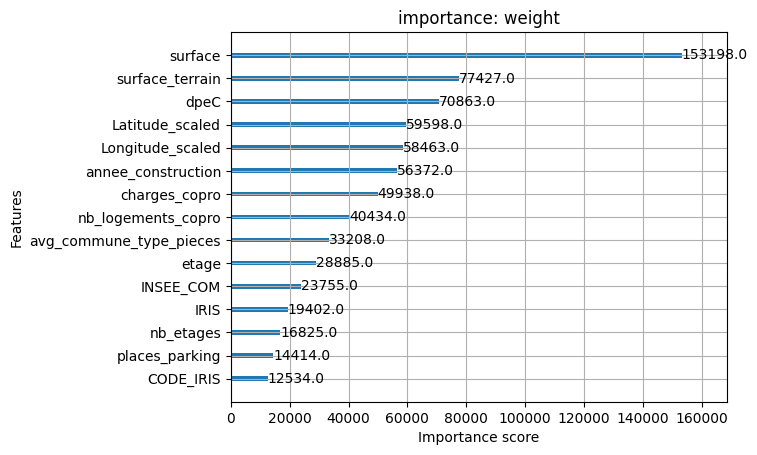

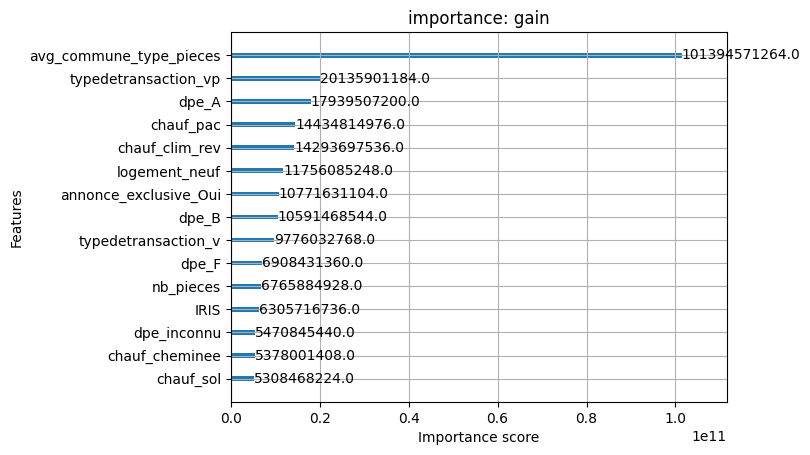

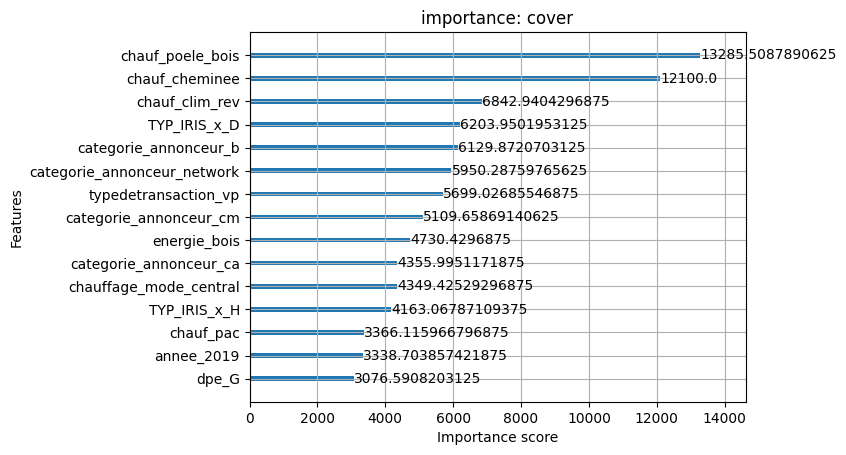

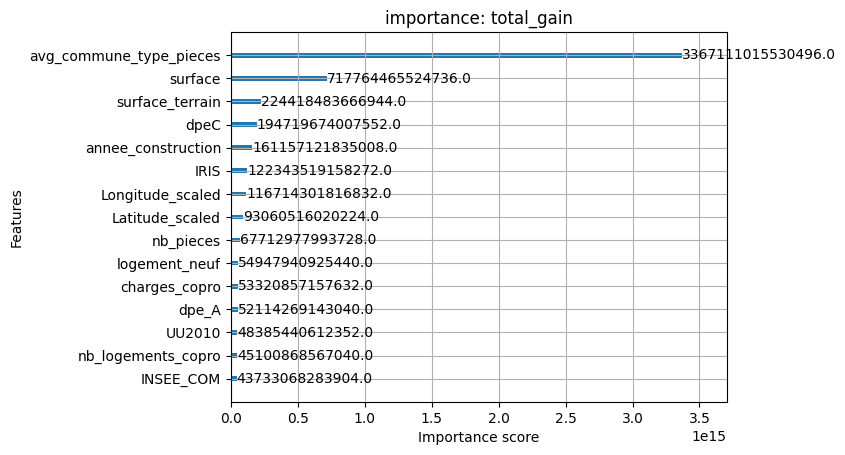

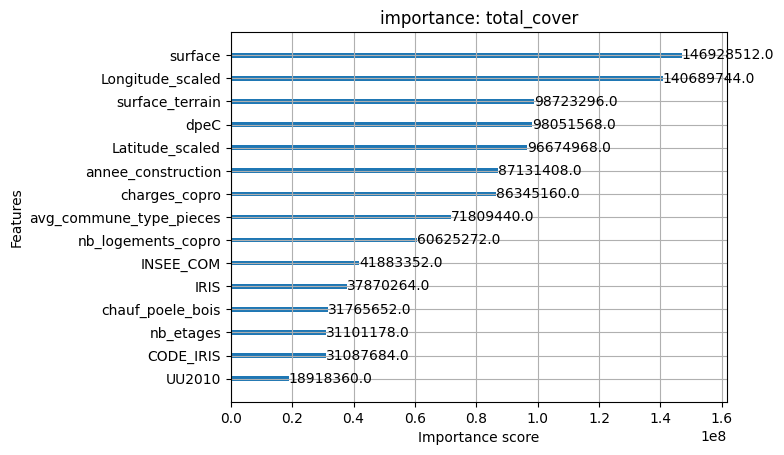

In [307]:
types= ['weight', 'gain', 'cover', 'total_gain', 'total_cover']

for f in types:
    xgb.plot_importance(xgb_ros ,max_num_features=15, importance_type=f, title='importance: '+f);

### predict

In [308]:
preds = xgb_ros.predict(test)

preds_maisons = xgb_ros.predict(test_maisons)
preds_maisons_moins5 = xgb_ros.predict(test_maisons_moins5)
preds_maisons_plus5 = xgb_ros.predict(test_maisons_plus5)

preds_appartements = xgb_ros.predict(test_appartements)
preds_appartements_moins3 = xgb_ros.predict(test_appartements_moins3)
preds_appartements_plus3 = xgb_ros.predict(test_appartements_plus3)

### MAE maisons/appartements

In [309]:
dict_metrics_xgboost['XGBoost ROS nb_pieces seuil'] = {}

In [310]:
print(f"MAE de XGBoost 10000 rounds : {abs(y_test['prix_bien'] - preds).mean()} sur {len(preds)} biens de test")
print(f"MAE de XGBoost 10000 rounds (focus test maisons): {abs(y_test_maisons['prix_bien'] - preds_maisons).mean()} sur {len(preds_maisons)} biens de test")
print(f"MAE de XGBoost 10000 rounds (focus test appartements): {abs(y_test_appartements['prix_bien'] - preds_appartements).mean()} sur {len(preds_appartements)} biens de test")

dict_metrics_xgboost['XGBoost ROS nb_pieces seuil']['MAE'] = abs(y_test['prix_bien'] - preds).mean()
dict_metrics_xgboost['XGBoost ROS nb_pieces seuil']['MAE maisons'] = abs(y_test_maisons['prix_bien'] - preds_maisons).mean()
dict_metrics_xgboost['XGBoost ROS nb_pieces seuil']['MAE appartements'] = abs(y_test_appartements['prix_bien'] - preds_appartements).mean()

MAE de XGBoost 10000 rounds : 42276.59296905476 sur 5127 biens de test
MAE de XGBoost 10000 rounds (focus test maisons): 56290.11279761905 sur 2625 biens de test
MAE de XGBoost 10000 rounds (focus test appartements): 27574.159096160573 sur 2502 biens de test


Focus sur les maisons => moins de 5 pièces vs plus de 5 pièces

In [311]:
print(f"MAE de XGBoost 10000 rounds (focus test maisons): {abs(y_test_maisons['prix_bien'] - preds_maisons).mean()} sur {len(preds_maisons)} biens de test")
print(f"MAE de XGBoost 10000 rounds (focus test maisons <= 5 pieces): {abs(y_test_maisons_moins5['prix_bien'] - preds_maisons_moins5).mean()} sur {len(preds_maisons_moins5)} biens de test")
print(f"MAE de XGBoost 10000 rounds (focus test maisons > 5 pieces): {abs(y_test_maisons_plus5['prix_bien'] - preds_maisons_plus5).mean()} sur {len(preds_maisons_plus5)} biens de test")

dict_metrics_xgboost['XGBoost ROS nb_pieces seuil']['MAE maisons <= 5 pieces'] = abs(y_test_maisons_moins5['prix_bien'] - preds_maisons_moins5).mean()
dict_metrics_xgboost['XGBoost ROS nb_pieces seuil']['MAE maisons > 5 pieces'] = abs(y_test_maisons_plus5['prix_bien'] - preds_maisons_plus5).mean()


MAE de XGBoost 10000 rounds (focus test maisons): 56290.11279761905 sur 2625 biens de test
MAE de XGBoost 10000 rounds (focus test maisons <= 5 pieces): 41776.815602312185 sur 1584 biens de test
MAE de XGBoost 10000 rounds (focus test maisons > 5 pieces): 78373.746570305 sur 1041 biens de test


Focus sur les appartements => moins de 3 pièces vs plus de 3 pièces

In [312]:
print(f"MAE de XGBoost 10000 rounds (focus test appartements): {abs(y_test_appartements['prix_bien'] - preds_appartements).mean()} sur {len(preds_appartements)} biens de test")
print(f"MAE de XGBoost 10000 rounds (focus test appartements <= 3 pieces): {abs(y_test_appartements_moins3['prix_bien'] - preds_appartements_moins3).mean()} sur {len(preds_appartements_moins3)} biens de test")
print(f"MAE de XGBoost 10000 rounds (focus test appartements > 3 pieces): {abs(y_test_appartements_plus3['prix_bien'] - preds_appartements_plus3).mean()} sur {len(preds_appartements_plus3)} biens de test")

dict_metrics_xgboost['XGBoost ROS nb_pieces seuil']['MAE appartements <= 3 pieces'] = abs(y_test_appartements_moins3['prix_bien'] - preds_appartements_moins3).mean()
dict_metrics_xgboost['XGBoost ROS nb_pieces seuil']['MAE appartements > 3 pieces'] = abs(y_test_appartements_plus3['prix_bien'] - preds_appartements_plus3).mean()

MAE de XGBoost 10000 rounds (focus test appartements): 27574.159096160573 sur 2502 biens de test
MAE de XGBoost 10000 rounds (focus test appartements <= 3 pieces): 20855.892273240457 sur 1467 biens de test
MAE de XGBoost 10000 rounds (focus test appartements > 3 pieces): 37096.572071256036 sur 1035 biens de test


Résultat légèrement moins bon après oversampling pour équilibre des classes +-3 pieces pour appartements et +-5 pieces pour maisons.
Notre MAE de train est très très faible, nous avons peut etre un overfitting.
Nous allons essayer l'undersampling.

## UnderSampling sur nb_pieces +-3 pour appartements et +-5 pour maisons

### Df pour UnderSampling maisons

In [313]:
df_rus_X_train_maisons = X_train_maisons
df_rus_X_train_maisons['prix_bien'] = y_train_maisons
df_rus_X_train_maisons_plus_moins5 = (X_train_sans_scaler_maisons.nb_pieces <= 5).astype('uint8')
print('Classes avant undersampling :', dict(pd.Series(df_rus_X_train_maisons_plus_moins5).value_counts()))

Classes avant undersampling : {1: np.int64(6288), 0: np.int64(4089)}


C:\Users\NKSP1012\AppData\Local\Temp\1\ipykernel_29396\4036649691.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_rus_X_train_maisons['prix_bien'] = y_train_maisons


In [314]:
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

### RandomUnderSampler maisons

In [315]:
rUs_maisons = RandomUnderSampler()
X_ru, y_ru = rUs_maisons.fit_resample(df_rus_X_train_maisons, df_rus_X_train_maisons_plus_moins5)
print('Classes après oversampling :', dict(pd.Series(y_ru).value_counts()))

Classes après oversampling : {0: np.int64(4089), 1: np.int64(4089)}


In [316]:
X_train_maisons_rus = X_ru.drop('prix_bien', axis=1)
y_train_maisons_rus = X_ru.prix_bien

### Df pour UnderSampling appartements

In [317]:
df_rus_X_train_appartements = X_train_appartements
df_rus_X_train_appartements['prix_bien'] = y_train_appartements
df_rus_X_train_appartements_plus_moins3 = (X_train_sans_scaler_appartements.nb_pieces <= 3).astype('uint8')
print('Classes avant oversampling :', dict(pd.Series(df_rus_X_train_appartements_plus_moins3).value_counts()))

Classes avant oversampling : {1: np.int64(5995), 0: np.int64(4197)}


C:\Users\NKSP1012\AppData\Local\Temp\1\ipykernel_29396\1578149802.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_rus_X_train_appartements['prix_bien'] = y_train_appartements


### RandomUnderSampler appartements

In [318]:
rUs_appartements = RandomUnderSampler()
X_ru, y_ru = rUs_appartements.fit_resample(df_rus_X_train_appartements, df_rus_X_train_appartements_plus_moins3)
print('Classes après oversampling :', dict(pd.Series(y_ru).value_counts()))

Classes après oversampling : {0: np.int64(4197), 1: np.int64(4197)}


In [319]:
X_train_appartements_rus = X_ru.drop('prix_bien', axis=1)
y_train_appartements_rus = X_ru.prix_bien

### X_train et y_train avec RUS

In [320]:
X_train_rus = pd.concat([X_train_maisons_rus, X_train_appartements_rus])
y_train_rus = pd.concat([y_train_maisons_rus, y_train_appartements_rus])

In [321]:
train_rus = xgb.DMatrix(data=X_train_rus, label=y_train_rus)

### XGBoost avec RUS (MAE : 42971)

In [322]:
params = {'colsample_bytree': 1.0, 'gamma': 0, 'learning_rate': 0.05, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 1000, 'subsample': 0.8, 'objective': 'reg:squarederror', 'eval_metric' : 'mae', 'booster' : 'gbtree'}

xgb_rus = xgb.train(params=params, dtrain=train_rus, num_boost_round=10000, evals=[(train_rus, 'train'), (test, 'eval')])


[0]	train-mae:116268.93388	eval-mae:113290.36323
[1]	train-mae:111914.61196	eval-mae:109563.70118
[2]	train-mae:107794.55408	eval-mae:106039.09476
[3]	train-mae:103928.01781	eval-mae:102718.70492
[4]	train-mae:100260.18195	eval-mae:99642.20947


c:\Users\NKSP1012\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:58:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "n_estimators" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[5]	train-mae:96741.13349	eval-mae:96699.93753
[6]	train-mae:93509.81617	eval-mae:94001.09929
[7]	train-mae:90418.01779	eval-mae:91429.64205
[8]	train-mae:87518.17730	eval-mae:88966.46018
[9]	train-mae:84825.47449	eval-mae:86732.50878
[10]	train-mae:82257.95140	eval-mae:84588.16121
[11]	train-mae:79880.93535	eval-mae:82613.15516
[12]	train-mae:77630.93215	eval-mae:80745.22078
[13]	train-mae:75469.63504	eval-mae:79034.35736
[14]	train-mae:73431.37240	eval-mae:77381.25638
[15]	train-mae:71587.99772	eval-mae:75870.54244
[16]	train-mae:69769.87714	eval-mae:74397.62071
[17]	train-mae:68023.97479	eval-mae:72977.92768
[18]	train-mae:66433.65469	eval-mae:71696.96840
[19]	train-mae:64948.12005	eval-mae:70476.53313
[20]	train-mae:63529.05414	eval-mae:69308.06302
[21]	train-mae:62188.88225	eval-mae:68247.49404
[22]	train-mae:60935.67967	eval-mae:67275.06118
[23]	train-mae:59753.79101	eval-mae:66311.39197
[24]	train-mae:58617.49013	eval-mae:65479.31740
[25]	train-mae:57587.94525	eval-mae:64659.261

### plot_importance

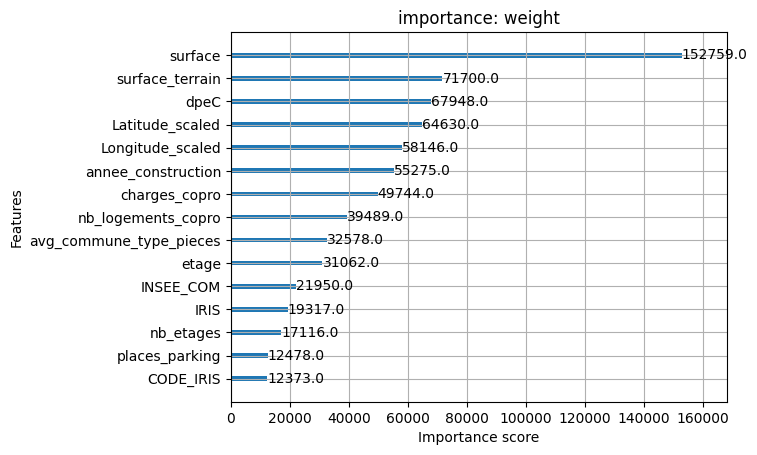

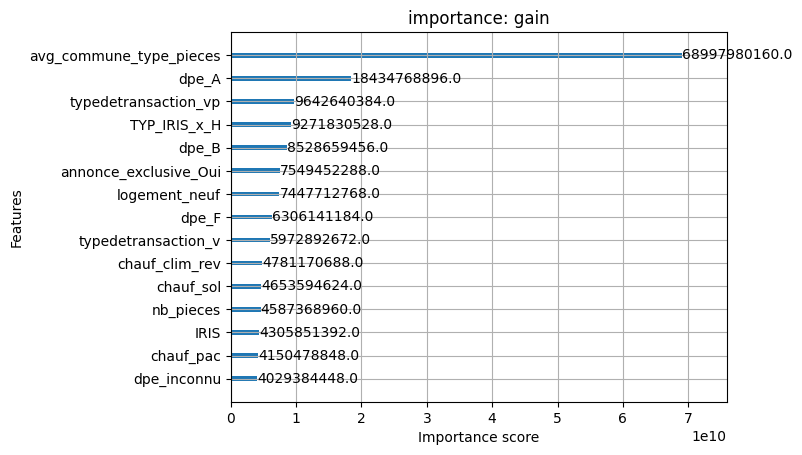

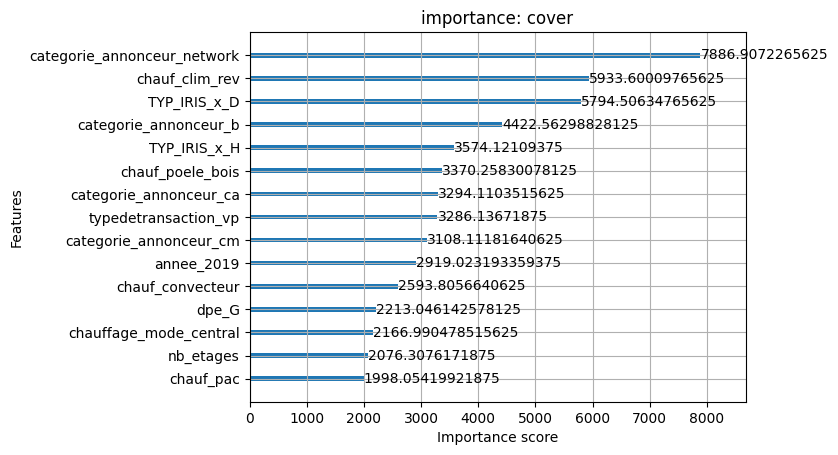

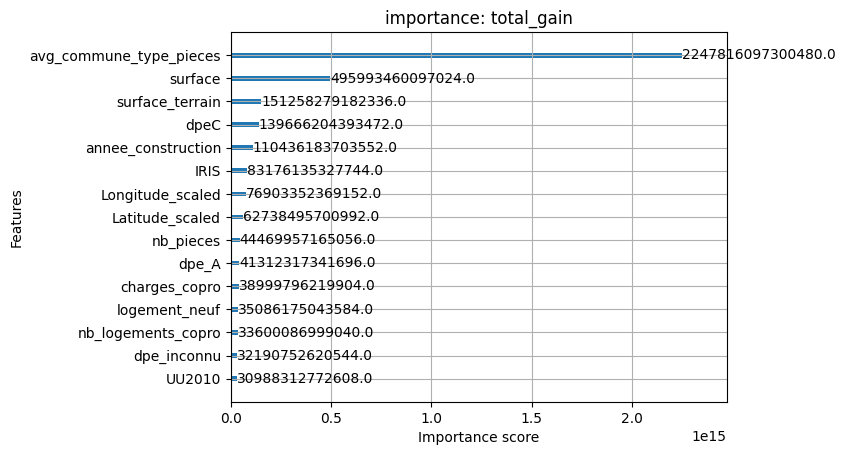

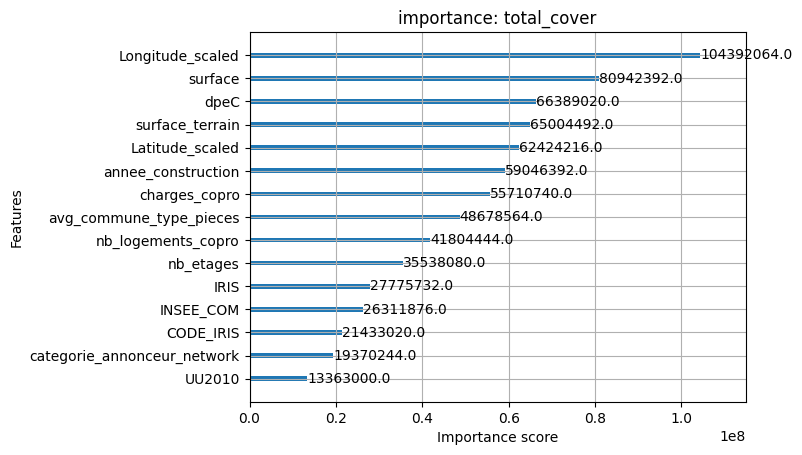

In [349]:
types= ['weight', 'gain', 'cover', 'total_gain', 'total_cover']

for f in types:
    xgb.plot_importance(xgb_rus ,max_num_features=15, importance_type=f, title='importance: '+f);

### predict

In [323]:
preds = xgb_rus.predict(test)

preds_maisons = xgb_rus.predict(test_maisons)
preds_maisons_moins5 = xgb_rus.predict(test_maisons_moins5)
preds_maisons_plus5 = xgb_rus.predict(test_maisons_plus5)

preds_appartements = xgb_rus.predict(test_appartements)
preds_appartements_moins3 = xgb_rus.predict(test_appartements_moins3)
preds_appartements_plus3 = xgb_rus.predict(test_appartements_plus3)

### MAE maisons/appartements

In [324]:
dict_metrics_xgboost['XGBoost RUS nb_pieces seuil'] = {}

In [325]:
print(f"MAE de XGBoost 10000 rounds : {abs(y_test['prix_bien'] - preds).mean()} sur {len(preds)} biens de test")
print(f"MAE de XGBoost 10000 rounds (focus test maisons): {abs(y_test_maisons['prix_bien'] - preds_maisons).mean()} sur {len(preds_maisons)} biens de test")
print(f"MAE de XGBoost 10000 rounds (focus test appartements): {abs(y_test_appartements['prix_bien'] - preds_appartements).mean()} sur {len(preds_appartements)} biens de test")

dict_metrics_xgboost['XGBoost RUS nb_pieces seuil']['MAE'] = abs(y_test['prix_bien'] - preds).mean()
dict_metrics_xgboost['XGBoost RUS nb_pieces seuil']['MAE maisons'] = abs(y_test_maisons['prix_bien'] - preds_maisons).mean()
dict_metrics_xgboost['XGBoost RUS nb_pieces seuil']['MAE appartements'] = abs(y_test_appartements['prix_bien'] - preds_appartements).mean()

MAE de XGBoost 10000 rounds : 42971.00262969024 sur 5127 biens de test
MAE de XGBoost 10000 rounds (focus test maisons): 57247.22735565476 sur 2625 biens de test
MAE de XGBoost 10000 rounds (focus test appartements): 27992.949110243055 sur 2502 biens de test


Focus sur les maisons => moins de 5 pièces vs plus de 5 pièces

In [326]:
print(f"MAE de XGBoost 10000 rounds (focus test maisons): {abs(y_test_maisons['prix_bien'] - preds_maisons).mean()} sur {len(preds_maisons)} biens de test")
print(f"MAE de XGBoost 10000 rounds (focus test maisons <= 5 pieces): {abs(y_test_maisons_moins5['prix_bien'] - preds_maisons_moins5).mean()} sur {len(preds_maisons_moins5)} biens de test")
print(f"MAE de XGBoost 10000 rounds (focus test maisons > 5 pieces): {abs(y_test_maisons_plus5['prix_bien'] - preds_maisons_plus5).mean()} sur {len(preds_maisons_plus5)} biens de test")

dict_metrics_xgboost['XGBoost RUS nb_pieces seuil']['MAE maisons <= 5 pieces'] = abs(y_test_maisons_moins5['prix_bien'] - preds_maisons_moins5).mean()
dict_metrics_xgboost['XGBoost RUS nb_pieces seuil']['MAE maisons > 5 pieces'] = abs(y_test_maisons_plus5['prix_bien'] - preds_maisons_plus5).mean()


MAE de XGBoost 10000 rounds (focus test maisons): 57247.22735565476 sur 2625 biens de test
MAE de XGBoost 10000 rounds (focus test maisons <= 5 pieces): 43265.413808495105 sur 1584 biens de test
MAE de XGBoost 10000 rounds (focus test maisons > 5 pieces): 78522.14825738473 sur 1041 biens de test


Focus sur les appartements => moins de 3 pièces vs plus de 3 pièces

In [327]:
print(f"MAE de XGBoost 10000 rounds (focus test appartements): {abs(y_test_appartements['prix_bien'] - preds_appartements).mean()} sur {len(preds_appartements)} biens de test")
print(f"MAE de XGBoost 10000 rounds (focus test appartements <= 3 pieces): {abs(y_test_appartements_moins3['prix_bien'] - preds_appartements_moins3).mean()} sur {len(preds_appartements_moins3)} biens de test")
print(f"MAE de XGBoost 10000 rounds (focus test appartements > 3 pieces): {abs(y_test_appartements_plus3['prix_bien'] - preds_appartements_plus3).mean()} sur {len(preds_appartements_plus3)} biens de test")

dict_metrics_xgboost['XGBoost RUS nb_pieces seuil']['MAE appartements <= 3 pieces'] = abs(y_test_appartements_moins3['prix_bien'] - preds_appartements_moins3).mean()
dict_metrics_xgboost['XGBoost RUS nb_pieces seuil']['MAE appartements > 3 pieces'] = abs(y_test_appartements_plus3['prix_bien'] - preds_appartements_plus3).mean()


MAE de XGBoost 10000 rounds (focus test appartements): 27992.949110243055 sur 2502 biens de test
MAE de XGBoost 10000 rounds (focus test appartements <= 3 pieces): 21209.879099299163 sur 1467 biens de test
MAE de XGBoost 10000 rounds (focus test appartements > 3 pieces): 37607.21356053744 sur 1035 biens de test


MAE similaire à OverSampling et XGBoost de base.

Idées :
* OverSampling/UnderSampling sur nb_pieces brut, pas de seuil à 3 ou 5 ...
* OverSampling/UnderSampling sur code postal

## OverSampling sur nb_pieces brut

Equilibre des classes sur X_train et X_test pour les maisons.

In [328]:
X_train_sans_scaler_maisons.nb_pieces.value_counts()

nb_pieces
5     4191
6     2114
4     1634
7      997
8      475
3      359
9      207
10     148
12      85
2       71
11      45
1       33
13      10
14       7
16       1
Name: count, dtype: int64

In [329]:
X_test_sans_scaler_maisons.nb_pieces.value_counts()

nb_pieces
5     1032
6      555
4      441
7      256
8      106
3       82
10      48
9       46
2       18
12      15
11      15
1       11
Name: count, dtype: int64

Equilibre des classes sur X_train et X_test pour les appartements.

In [330]:
X_train_sans_scaler_appartements.nb_pieces.value_counts()

nb_pieces
3     3520
4     2727
2     2123
5     1110
1      352
6      280
7       47
8       21
10       4
9        4
11       3
15       1
Name: count, dtype: int64

In [331]:
X_test_sans_scaler_appartements.nb_pieces.value_counts()

nb_pieces
3     862
4     676
2     517
5     266
1      88
6      69
7      13
8       8
10      2
12      1
Name: count, dtype: int64

### Df pour OverSampling maisons

In [332]:
df_ros_nb_pieces_X_train_maisons = X_train_maisons
df_ros_nb_pieces_X_train_maisons['prix_bien'] = y_train_maisons
df_ros_nb_pieces_X_train_maisons_nb_pieces = X_train_sans_scaler_maisons.nb_pieces
print('Classes avant oversampling :', dict(pd.Series(df_ros_nb_pieces_X_train_maisons_nb_pieces).value_counts()))

Classes avant oversampling : {5: np.int64(4191), 6: np.int64(2114), 4: np.int64(1634), 7: np.int64(997), 8: np.int64(475), 3: np.int64(359), 9: np.int64(207), 10: np.int64(148), 12: np.int64(85), 2: np.int64(71), 11: np.int64(45), 1: np.int64(33), 13: np.int64(10), 14: np.int64(7), 16: np.int64(1)}


C:\Users\NKSP1012\AppData\Local\Temp\1\ipykernel_29396\1606789023.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ros_nb_pieces_X_train_maisons['prix_bien'] = y_train_maisons


In [333]:
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

### RandomOverSampler maisons

In [334]:
rOs_nb_pieces_maisons = RandomOverSampler()
X_ro, y_ro = rOs_nb_pieces_maisons.fit_resample(df_ros_nb_pieces_X_train_maisons, df_ros_nb_pieces_X_train_maisons_nb_pieces)
print('Classes après oversampling :', dict(pd.Series(y_ro).value_counts()))

Classes après oversampling : {5: np.int64(4191), 6: np.int64(4191), 4: np.int64(4191), 8: np.int64(4191), 7: np.int64(4191), 3: np.int64(4191), 9: np.int64(4191), 11: np.int64(4191), 10: np.int64(4191), 12: np.int64(4191), 2: np.int64(4191), 1: np.int64(4191), 14: np.int64(4191), 13: np.int64(4191), 16: np.int64(4191)}


In [335]:
X_train_maisons_ros_nb_pieces = X_ro.drop('prix_bien', axis=1)
y_train_maisons_ros_nb_pieces = X_ro.prix_bien

### Df pour OverSampling appartements

In [336]:
df_ros_nb_pieces_X_train_appartements = X_train_appartements
df_ros_nb_pieces_X_train_appartements['prix_bien'] = y_train_appartements
df_ros_nb_pieces_X_train_appartements_nb_pieces = X_train_sans_scaler_appartements.nb_pieces
print('Classes avant oversampling :', dict(pd.Series(df_ros_nb_pieces_X_train_appartements_nb_pieces).value_counts()))

Classes avant oversampling : {3: np.int64(3520), 4: np.int64(2727), 2: np.int64(2123), 5: np.int64(1110), 1: np.int64(352), 6: np.int64(280), 7: np.int64(47), 8: np.int64(21), 10: np.int64(4), 9: np.int64(4), 11: np.int64(3), 15: np.int64(1)}


C:\Users\NKSP1012\AppData\Local\Temp\1\ipykernel_29396\1032996800.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ros_nb_pieces_X_train_appartements['prix_bien'] = y_train_appartements


### RandomOverSampler appartements

In [337]:
rOs_nb_pieces_appartements = RandomOverSampler()
X_ro, y_ro = rOs_nb_pieces_appartements.fit_resample(df_ros_nb_pieces_X_train_appartements, df_ros_nb_pieces_X_train_appartements_nb_pieces)
print('Classes après oversampling :', dict(pd.Series(y_ro).value_counts()))

Classes après oversampling : {3: np.int64(3520), 4: np.int64(3520), 1: np.int64(3520), 2: np.int64(3520), 5: np.int64(3520), 6: np.int64(3520), 8: np.int64(3520), 7: np.int64(3520), 10: np.int64(3520), 9: np.int64(3520), 11: np.int64(3520), 15: np.int64(3520)}


In [338]:
X_train_appartements_ros_nb_pieces = X_ro.drop('prix_bien', axis=1)
y_train_appartements_ros_nb_pieces = X_ro.prix_bien

### X_train et y_train avec ROS

In [339]:
X_train_ros_nb_pieces = pd.concat([X_train_maisons_ros_nb_pieces, X_train_appartements_ros_nb_pieces])
y_train_ros_nb_pieces = pd.concat([y_train_maisons_ros_nb_pieces, y_train_appartements_ros_nb_pieces])

In [340]:
train_ros_nb_pieces = xgb.DMatrix(data=X_train_ros_nb_pieces, label=y_train_ros_nb_pieces)

### XGBoost avec ROS (MAE : 43628)

In [341]:
params = {'colsample_bytree': 1.0, 'gamma': 0, 'learning_rate': 0.05, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 1000, 'subsample': 0.8, 'objective': 'reg:squarederror', 'eval_metric' : 'mae', 'booster' : 'gbtree'}

xgb_ros_nb_pieces = xgb.train(params=params, dtrain=train_ros_nb_pieces, num_boost_round=10000, evals=[(train_ros_nb_pieces, 'train'), (test, 'eval')])


c:\Users\NKSP1012\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:02:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "n_estimators" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[0]	train-mae:167285.74991	eval-mae:135454.29121
[1]	train-mae:159850.46232	eval-mae:130933.20451
[2]	train-mae:152836.21575	eval-mae:126659.72127
[3]	train-mae:146172.57064	eval-mae:122650.05447
[4]	train-mae:139882.40393	eval-mae:118814.98162
[5]	train-mae:133848.06076	eval-mae:115101.79080
[6]	train-mae:128176.22526	eval-mae:111816.68790
[7]	train-mae:122807.48969	eval-mae:108624.21933
[8]	train-mae:117689.15566	eval-mae:105645.74246
[9]	train-mae:112859.58592	eval-mae:102859.49297
[10]	train-mae:108284.35018	eval-mae:100177.70311
[11]	train-mae:103951.08732	eval-mae:97623.34466
[12]	train-mae:99864.98551	eval-mae:95386.99762
[13]	train-mae:95941.60470	eval-mae:93169.52005
[14]	train-mae:92276.08154	eval-mae:91067.61020
[15]	train-mae:88758.14727	eval-mae:89056.12559
[16]	train-mae:85435.94485	eval-mae:87201.86249
[17]	train-mae:82263.76285	eval-mae:85387.85433
[18]	train-mae:79348.05234	eval-mae:83836.82536
[19]	train-mae:76542.33890	eval-mae:82323.08719
[20]	train-mae:73934.01047	

### plot_importance

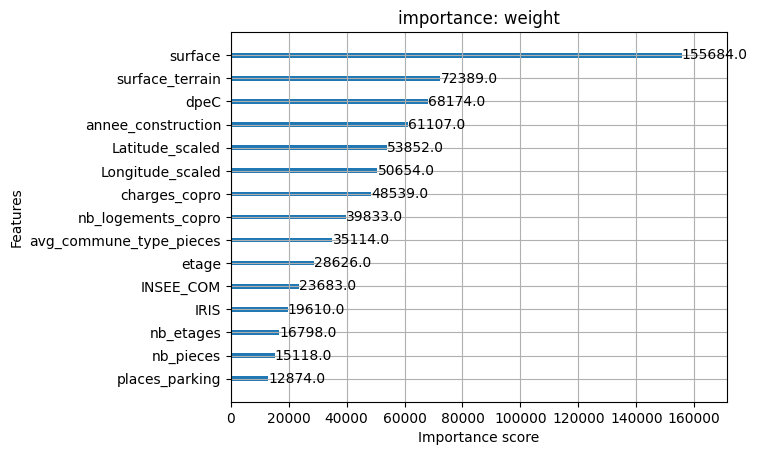

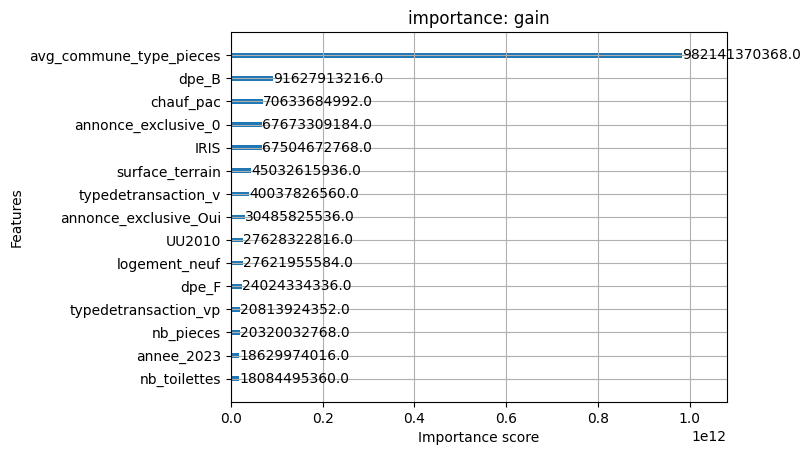

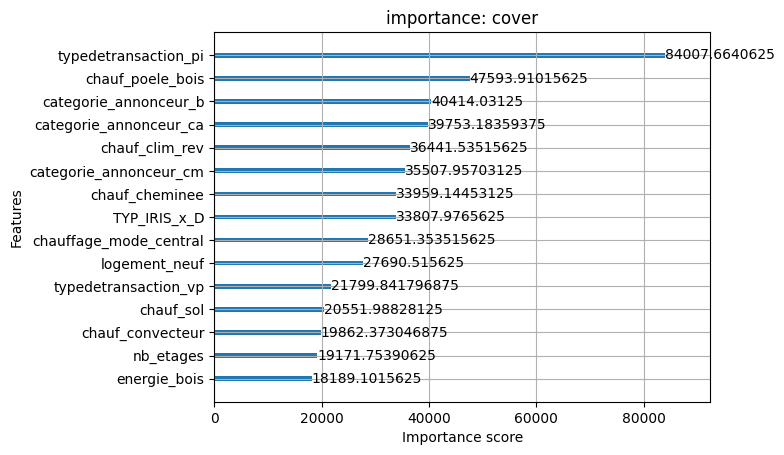

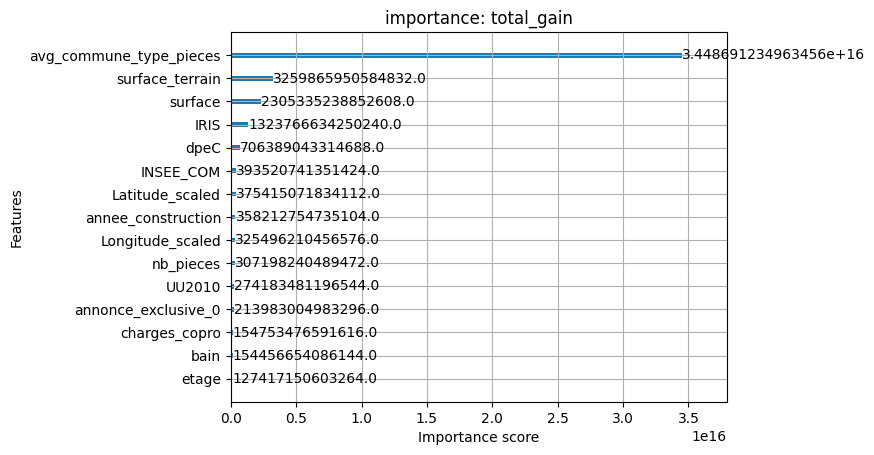

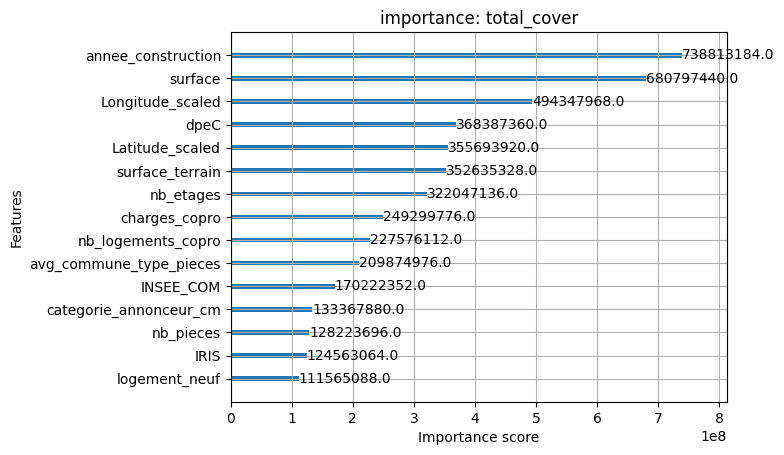

In [342]:
types= ['weight', 'gain', 'cover', 'total_gain', 'total_cover']

for f in types:
    xgb.plot_importance(xgb_ros_nb_pieces ,max_num_features=15, importance_type=f, title='importance: '+f);

### predict

In [343]:
preds = xgb_ros_nb_pieces.predict(test)

preds_maisons = xgb_ros_nb_pieces.predict(test_maisons)
preds_maisons_moins5 = xgb_ros_nb_pieces.predict(test_maisons_moins5)
preds_maisons_plus5 = xgb_ros_nb_pieces.predict(test_maisons_plus5)

preds_appartements = xgb_ros_nb_pieces.predict(test_appartements)
preds_appartements_moins3 = xgb_ros_nb_pieces.predict(test_appartements_moins3)
preds_appartements_plus3 = xgb_ros_nb_pieces.predict(test_appartements_plus3)

### MAE maisons/appartements

In [344]:
dict_metrics_xgboost['XGBoost ROS nb_pieces'] = {}

In [345]:
print(f"MAE de XGBoost 10000 rounds : {abs(y_test['prix_bien'] - preds).mean()} sur {len(preds)} biens de test")
print(f"MAE de XGBoost 10000 rounds (focus test maisons): {abs(y_test_maisons['prix_bien'] - preds_maisons).mean()} sur {len(preds_maisons)} biens de test")
print(f"MAE de XGBoost 10000 rounds (focus test appartements): {abs(y_test_appartements['prix_bien'] - preds_appartements).mean()} sur {len(preds_appartements)} biens de test")

dict_metrics_xgboost['XGBoost ROS nb_pieces']['MAE'] = abs(y_test['prix_bien'] - preds).mean()
dict_metrics_xgboost['XGBoost ROS nb_pieces']['MAE maisons'] = abs(y_test_maisons['prix_bien'] - preds_maisons).mean()
dict_metrics_xgboost['XGBoost ROS nb_pieces']['MAE appartements'] = abs(y_test_appartements['prix_bien'] - preds_appartements).mean()

MAE de XGBoost 10000 rounds : 43628.38433667654 sur 5127 biens de test
MAE de XGBoost 10000 rounds (focus test maisons): 58564.62540922619 sur 2625 biens de test
MAE de XGBoost 10000 rounds (focus test appartements): 27957.867623869653 sur 2502 biens de test


Focus sur les maisons => moins de 5 pièces vs plus de 5 pièces

In [346]:
print(f"MAE de XGBoost 10000 rounds (focus test maisons): {abs(y_test_maisons['prix_bien'] - preds_maisons).mean()} sur {len(preds_maisons)} biens de test")
print(f"MAE de XGBoost 10000 rounds (focus test maisons <= 5 pieces): {abs(y_test_maisons_moins5['prix_bien'] - preds_maisons_moins5).mean()} sur {len(preds_maisons_moins5)} biens de test")
print(f"MAE de XGBoost 10000 rounds (focus test maisons > 5 pieces): {abs(y_test_maisons_plus5['prix_bien'] - preds_maisons_plus5).mean()} sur {len(preds_maisons_plus5)} biens de test")

dict_metrics_xgboost['XGBoost ROS nb_pieces']['MAE maisons <= 5 pieces'] = abs(y_test_maisons_moins5['prix_bien'] - preds_maisons_moins5).mean()
dict_metrics_xgboost['XGBoost ROS nb_pieces']['MAE maisons > 5 pieces'] = abs(y_test_maisons_plus5['prix_bien'] - preds_maisons_plus5).mean()


MAE de XGBoost 10000 rounds (focus test maisons): 58564.62540922619 sur 2625 biens de test
MAE de XGBoost 10000 rounds (focus test maisons <= 5 pieces): 42453.80951359296 sur 1584 biens de test
MAE de XGBoost 10000 rounds (focus test maisons > 5 pieces): 83079.06573457012 sur 1041 biens de test


Focus sur les appartements => moins de 3 pièces vs plus de 3 pièces

In [347]:
print(f"MAE de XGBoost 10000 rounds (focus test appartements): {abs(y_test_appartements['prix_bien'] - preds_appartements).mean()} sur {len(preds_appartements)} biens de test")
print(f"MAE de XGBoost 10000 rounds (focus test appartements <= 3 pieces): {abs(y_test_appartements_moins3['prix_bien'] - preds_appartements_moins3).mean()} sur {len(preds_appartements_moins3)} biens de test")
print(f"MAE de XGBoost 10000 rounds (focus test appartements > 3 pieces): {abs(y_test_appartements_plus3['prix_bien'] - preds_appartements_plus3).mean()} sur {len(preds_appartements_plus3)} biens de test")

dict_metrics_xgboost['XGBoost ROS nb_pieces']['MAE appartements <= 3 pieces'] = abs(y_test_appartements_moins3['prix_bien'] - preds_appartements_moins3).mean()
dict_metrics_xgboost['XGBoost ROS nb_pieces']['MAE appartements > 3 pieces'] = abs(y_test_appartements_plus3['prix_bien'] - preds_appartements_plus3).mean()

MAE de XGBoost 10000 rounds (focus test appartements): 27957.867623869653 sur 2502 biens de test
MAE de XGBoost 10000 rounds (focus test appartements <= 3 pieces): 21155.95108932984 sur 1467 biens de test
MAE de XGBoost 10000 rounds (focus test appartements > 3 pieces): 37598.84497282609 sur 1035 biens de test


In [348]:
dict_metrics_xgboost

{'XGBoost': {'MAE': np.float64(42105.31259333248),
  'MAE maisons': np.float64(55953.45099404762),
  'MAE appartements': np.float64(27576.39041032799),
  'MAE maisons <= 5 pieces': np.float64(41494.783242582074),
  'MAE maisons > 5 pieces': np.float64(77953.95984930356),
  'MAE appartements <= 3 pieces': np.float64(20627.330594697938),
  'MAE appartements > 3 pieces': np.float64(37425.92736639493)},
 'XGBoost ROS nb_pieces seuil': {'MAE': np.float64(42276.59296905476),
  'MAE maisons': np.float64(56290.11279761905),
  'MAE appartements': np.float64(27574.159096160573),
  'MAE maisons <= 5 pieces': np.float64(41776.815602312185),
  'MAE maisons > 5 pieces': np.float64(78373.746570305),
  'MAE appartements <= 3 pieces': np.float64(20855.892273240457),
  'MAE appartements > 3 pieces': np.float64(37096.572071256036)},
 'XGBoost RUS nb_pieces seuil': {'MAE': np.float64(42971.00262969024),
  'MAE maisons': np.float64(57247.22735565476),
  'MAE appartements': np.float64(27992.949110243055),
 

In [352]:
rows = []

for method, metrics in dict_metrics_xgboost.items():
    for metric_name, value in metrics.items():
        rows.append({
            'Méthode': method,
            'Catégorie': metric_name,
            'MAE': value
        })

df_results = pd.DataFrame(rows)

# Affichage du DataFrame
display(df_results)

,Méthode,Catégorie,MAE
0,XGBoost,MAE,42105.312593
1,XGBoost,MAE maisons,55953.450994
2,XGBoost,MAE appartements,27576.390410
3,XGBoost,MAE maisons <= 5 pieces,41494.783243
4,XGBoost,MAE maisons > 5 pieces,77953.959849
5,XGBoost,MAE appartements <= 3 pieces,20627.330595
6,XGBoost,MAE appartements > 3 pieces,37425.927366
7,XGBoost ROS nb_pieces seuil,MAE,42276.592969
8,XGBoost ROS nb_pieces seuil,MAE maisons,56290.112798
9,XGBoost ROS nb_pieces seuil,MAE appartements,27574.159096


In [353]:
df_results.sort_values(by='MAE', ascending=True)

,Méthode,Catégorie,MAE
5,XGBoost,MAE appartements <= 3 pieces,20627.330595
12,XGBoost ROS nb_pieces seuil,MAE appartements <= 3 pieces,20855.892273
26,XGBoost ROS nb_pieces,MAE appartements <= 3 pieces,21155.951089
19,XGBoost RUS nb_pieces seuil,MAE appartements <= 3 pieces,21209.879099
9,XGBoost ROS nb_pieces seuil,MAE appartements,27574.159096
2,XGBoost,MAE appartements,27576.390410
23,XGBoost ROS nb_pieces,MAE appartements,27957.867624
16,XGBoost RUS nb_pieces seuil,MAE appartements,27992.949110
13,XGBoost ROS nb_pieces seuil,MAE appartements > 3 pieces,37096.572071
6,XGBoost,MAE appartements > 3 pieces,37425.927366
